# Análisis de un chat de WhatsApp

## Introducción

En este proyecto se analiza una conversación grupal exportada desde WhatsApp con el objetivo de identificar patrones de participación, actividad temporal y uso del lenguaje entre sus integrantes.

El análisis incluye métricas como el número de mensajes enviados por usuario, cantidad y promedio de palabras, uso de emojis, actividad por día de la semana y hora del día, así como un análisis de las palabras y adjetivos más utilizados.

Debido a que la conversación contiene información personal, se realizó un proceso de anonimización antes del análisis. Los usuarios fueron sustituidos por identificadores como `Usuario_1`, `Usuario_2`, etc., mientras que información sensible presente dentro de los mensajes, como nombres, correos electrónicos, números telefónicos y datos financieros, fue reemplazada por etiquetas genéricas.

## 1. Carga y preparación de los datos

Primero se importan las librerías necesarias y se carga el archivo de texto generado por la exportación de WhatsApp.

La exportación contiene tanto mensajes de usuarios como eventos internos de WhatsApp y mensajes que ocupan múltiples líneas, por lo que es necesario procesar el archivo antes de convertirlo en un conjunto de datos estructurado.

### MousukeHerramientas

In [1]:
%pip install nltk emoji spacy wordcloud

Note: you may need to restart the kernel to use updated packages.


In [2]:
!python -m spacy download es_core_news_sm

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     -------------- ------------------------- 4.7/12.9 MB 35.7 MB/s eta 0:00:01
     ---------------------------------------- 12.9/12.9 MB 57.6 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


### Librerias, modelo and data loading

In [ ]:
import re
from pathlib import Path
from collections import Counter

import emoji
import matplotlib.pyplot as plt
import pandas as pd
import spacy
import nltk

from wordcloud import WordCloud

nltk.download("stopwords")
nlp = spacy.load("es_core_news_sm")

DATA_PATH = Path("../data/raw/_chat.txt")

with open(DATA_PATH, "r", encoding="utf-8") as file:
    chat = file.read()

[nltk_data] Downloading package stopwords to C:\Users\David
[nltk_data]     Durazo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 2. Parsing de los mensajes

Una línea del archivo exportado no necesariamente representa un mensaje completo. Algunos mensajes contienen saltos de línea y la exportación también incluye eventos generados automáticamente por WhatsApp.

Se utilizan expresiones regulares para identificar el inicio de cada mensaje y separar tres elementos principales:

- Fecha y hora del mensaje.
- Usuario que envió el mensaje.
- Contenido del mensaje.

Las líneas que no contienen un nuevo timestamp se consideran continuación del mensaje anterior, mientras que los eventos internos de WhatsApp son descartados.

In [4]:
type(chat)

str

In [5]:
print(len(chat))
print(chat[:1000])

68238
07/11/23, 11:40 am - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*
07/11/23, 11:40 am - This chat has added privacy for your phone number. Tap to learn more.
07/11/23, 11:40 am - ~ Diego Torres created community "Comunidad LCC"
07/11/23, 11:40 am - Welcome to the community!
07/11/23, 11:41 am - ~ Diego Torres added the group "OfertasBeta LCC"
07/11/23, 12:30 pm - G_U is now a community admin
07/11/23, 12:33 pm - G_U: Gente, Coordinación me pidió que les informara que estamos haciendo una colecta y que mañana es importante que todos procuren traer un kg de frijol (la bolsa de granos de frijol crudos).

ES MUY IMPORTANTE QUE TODOS HAGAN SU MAYOR ESFUERZO POR CONTRIBUIR, LA COLECTA ES PARA MAÑANA.
07/11/23, 12:50 pm - G_U: <Media omitted>
07/11/23, 12:57 pm - Only community admins can add groups. Members can suggest groups for admin approval.
07/11/23, 12:58 pm - ~ Amado Rosas is now a community admin
07/11/23,

In [6]:
lines = chat.splitlines()

print(type(lines))
print(len(lines))

<class 'list'>
780


In [7]:
lines[0]
lines[1]
lines[2]


'07/11/23, 11:40\u202fam - ~\u202fDiego Torres created community "Comunidad LCC"'

In [8]:
for line in lines[:30]:
    print(repr(line))

'07/11/23, 11:40\u202fam - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*'
'07/11/23, 11:40\u202fam - This chat has added privacy for your phone number. Tap to learn more.'
'07/11/23, 11:40\u202fam - ~\u202fDiego Torres created community "Comunidad LCC"'
'07/11/23, 11:40\u202fam - Welcome to the community!'
'07/11/23, 11:41\u202fam - ~\u202fDiego Torres added the group "OfertasBeta LCC"'
'07/11/23, 12:30\u202fpm - G_U is now a community admin'
'07/11/23, 12:33\u202fpm - G_U: Gente, Coordinación me pidió que les informara que estamos haciendo una colecta y que mañana es importante que todos procuren traer un kg de frijol (la bolsa de granos de frijol crudos).'
''
'ES MUY IMPORTANTE QUE TODOS HAGAN SU MAYOR ESFUERZO POR CONTRIBUIR, LA COLECTA ES PARA MAÑANA.'
'07/11/23, 12:50\u202fpm - G_U: <Media omitted>'
'07/11/23, 12:57\u202fpm - Only community admins can add groups. Members can suggest groups for admin approval.

Aquí solo queremos entender el patron para saber donde empieza un mensaje

In [9]:
pattern = r"^(\d{2}/\d{2}/\d{2}, \d{1,2}:\d{2}\s*[ap]m) - (.*?): (.*)"

for line in lines[:30]:
    match = re.match(pattern, line)

    if match:
        print("TIMESTAMP:", repr(match.group(1)))
        print("USER:     ", repr(match.group(2)))
        print("MESSAGE:  ", repr(match.group(3)))
        print()

TIMESTAMP: '07/11/23, 12:33\u202fpm'
USER:      'G_U'
MESSAGE:   'Gente, Coordinación me pidió que les informara que estamos haciendo una colecta y que mañana es importante que todos procuren traer un kg de frijol (la bolsa de granos de frijol crudos).'

TIMESTAMP: '07/11/23, 12:50\u202fpm'
USER:      'G_U'
MESSAGE:   '<Media omitted>'

TIMESTAMP: '07/11/23, 2:15\u202fpm'
USER:      '+52 662 315 0131'
MESSAGE:   'dice Sonia que es *exclusivamente* frijol'

TIMESTAMP: '07/11/23, 6:22\u202fpm'
USER:      'G_U'
MESSAGE:   '⚠️Recordatorio: Gente, Coordinación me pidió que les informara que estamos haciendo una colecta y que mañana es importante que todos procuren traer un kg de frijol (la bolsa de granos de frijol crudos).'

TIMESTAMP: '07/11/23, 6:23\u202fpm'
USER:      'G_U'
MESSAGE:   'Tambien esto:'

TIMESTAMP: '16/11/23, 9:59\u202fam'
USER:      '+52 662 167 8294'
MESSAGE:   'Les reenvío este correo del Dr. Jesús '



Vemos que pusieron los usuarios.

In [10]:
messages = []
current_message = None

for line in lines[:30]:
    match = re.match(pattern, line)

    if match:
        current_message = {
            "timestamp": match.group(1),
            "user": match.group(2),
            "message": match.group(3)
        }

        messages.append(current_message)

    elif current_message is not None:
        current_message["message"] += "\n" + line

In [11]:
for message in messages:
    print(message)
    print("-" * 50)

{'timestamp': '07/11/23, 12:33\u202fpm', 'user': 'G_U', 'message': 'Gente, Coordinación me pidió que les informara que estamos haciendo una colecta y que mañana es importante que todos procuren traer un kg de frijol (la bolsa de granos de frijol crudos).\n\nES MUY IMPORTANTE QUE TODOS HAGAN SU MAYOR ESFUERZO POR CONTRIBUIR, LA COLECTA ES PARA MAÑANA.'}
--------------------------------------------------
{'timestamp': '07/11/23, 12:50\u202fpm', 'user': 'G_U', 'message': '<Media omitted>\n07/11/23, 12:57\u202fpm - Only community admins can add groups. Members can suggest groups for admin approval.\n07/11/23, 12:58\u202fpm - ~\u202fAmado Rosas is now a community admin\n07/11/23, 12:59\u202fpm - ~\u202fFermin is now a community admin\n07/11/23, 12:59\u202fpm - El 🛏🦁 (Gustabo) is now a community admin\n07/11/23, 12:59\u202fpm - +1 (949) 304-3180 is now a community admin\n07/11/23, 12:59\u202fpm - ~\u202fOmar P is now a community admin\n07/11/23, 1:00\u202fpm - +52 662 298 3066 is now a commu

Conteo de mensajes en el chat

In [12]:
#Regex que podemos utilizar
timestamp_pattern = r"^(\d{2}/\d{2}/\d{2}, \d{1,2}:\d{2}\s*[ap]m) - "
message_pattern = r"^(\d{2}/\d{2}/\d{2}, \d{1,2}:\d{2}\s*[ap]m) - (.*?): (.*)"


messages = []
current_message = None

for line in lines:

    message_match = re.match(message_pattern, line)
    timestamp_match = re.match(timestamp_pattern, line)

    if message_match:
        current_message = {
            "timestamp": message_match.group(1).replace("\u202f", " "),
            "user": message_match.group(2),
            "message": message_match.group(3)
        }

        messages.append(current_message)

    elif timestamp_match:
        current_message = None

    elif current_message is not None:
        current_message["message"] += "\n" + line


In [13]:
print(f"Mensajes encontrados: {len(messages)}")

Mensajes encontrados: 390


In [14]:
for i, line in enumerate(lines):
    if line.startswith("["):
        print(i, repr(line))
        break

In [15]:
print("Total de líneas:", len(lines))
print()

for line in lines[-20:]:
    print(repr(line))

Total de líneas: 780

'08/09/26, 6:22\u202fpm - +52 662 268 7744: https://docs.google.com/forms/d/e/1FAIpQLSfuH_s_xQllaDSH-7YR2ZQeVQgRnKsFKxAkWM5MImGJqLWu_w/viewform?usp=publish-editor'
'10/09/26, 12:43\u202fpm - +52 662 268 7744: Hola compañeros, el día de hoy tuvimos una junta con sonia y hemos llegado a un acuerdo.'
'El día Lunes 14 de Septiembre se hará una junta a las 11:00AM, es de extrema importancia y urgencia que asistan ya que ahí se discutirá todo el tema del centro de cómputo y quien no esté presente no se enterará de los requerimientos para entrar ya que sea abierto, esperamos su asistencia'
'10/09/26, 4:45\u202fpm - +52 631 125 1255 assigned +52 662 268 7744 as the new owner'
'10/09/26, 6:28\u202fpm - +52 662 449 3477: buen día gente, aquí está el forms para las playeras, se cierra el 18 de septiembre '
' https://forms.gle/gYKNWawtf56PnWFq8'
'14/09/26, 8:18\u202fam - +52 662 268 7744: Hola compañeros, solo para recordarles que el dia de hoy a las 11:00AM sera la junta en 

In [16]:
for message in messages[-10:]:
    print("TIMESTAMP:", message["timestamp"])
    print("USER:", message["user"])
    print("MESSAGE:", message["message"])
    print("-" * 50)

TIMESTAMP: 17/09/26, 11:00 am
USER: +52 662 127 2301
MESSAGE: Holaa, oigan, los que falten en firmar la hoja del cc, estoy afuera de el 3k4, en una banca al lado de la calle, recibiendo firmas de 11 am a 12 pm y de nuevo de 3pm a 4pm, los que quieran firmar pasen conmigo por favor.
--------------------------------------------------
TIMESTAMP: 17/09/26, 3:23 pm
USER: +52 662 467 9029
MESSAGE: <Media omitted>
--------------------------------------------------
TIMESTAMP: 17/09/26, 8:42 pm
USER: +52 662 449 3477
MESSAGE: mañana a las 11 será la segunda y última entrega de libretas, igual en las mesitas de afuera
--------------------------------------------------
TIMESTAMP: 18/09/26, 8:53 am
USER: +52 662 467 9029
MESSAGE: <Media omitted>
--------------------------------------------------
TIMESTAMP: 18/09/26, 11:19 am
USER: +52 662 467 9029
MESSAGE: Oigan, este es el último día que tendremos las hojas con las firmas antes de que se las entreguemos a Sonia. Aquí las traeré, pueden mandarme m

### Creamos nuestro DataFrame

In [17]:
df = pd.DataFrame(messages)

df.head()

,timestamp,user,message
0,"07/11/23, 12:33 pm",G_U,"Gente, Coordinación me pidió que les informara..."
1,"07/11/23, 12:50 pm",G_U,<Media omitted>
2,"07/11/23, 2:15 pm",+52 662 315 0131,dice Sonia que es *exclusivamente* frijol
3,"07/11/23, 6:22 pm",G_U,"⚠️Recordatorio: Gente, Coordinación me pidió q..."
4,"07/11/23, 6:23 pm",G_U,Tambien esto:


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  390 non-null    object
 1   user       390 non-null    object
 2   message    390 non-null    object
dtypes: object(3)
memory usage: 9.3+ KB


Cambiamos el formato de la fecha y hora de los mensajes para hacerlo tipo datetime

In [19]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d/%m/%y, %I:%M %p"
)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  390 non-null    datetime64[ns]
 1   user       390 non-null    object        
 2   message    390 non-null    object        
dtypes: datetime64[ns](1), object(2)
memory usage: 9.3+ KB


In [21]:
df["user"].nunique()

28

Conteo de mensajes por usuario

In [22]:
df["user"].value_counts()

user
+52 631 125 1255     76
+52 662 111 6493     67
+52 662 268 7744     41
+52 662 167 8294     37
+52 662 315 0131     35
+52 662 296 2616     22
G_U                  20
+52 662 426 6490     17
+52 637 123 2727     11
+52 662 449 3477      9
+52 662 106 3537      8
+52 662 467 9029      8
+52 662 353 5181      7
+52 662 460 0089      6
+52 662 373 9949      6
El 🛏🦁 (Gustabo)       4
+52 662 139 3528      3
+52 662 444 6412      2
+1 (949) 304-3180     2
+52 662 344 4731      1
+52 662 137 3409      1
+52 662 501 3191      1
+52 662 432 8446      1
+52 662 452 0190      1
+52 662 448 3992      1
Christian             1
+52 662 404 4296      1
+52 662 127 2301      1
Name: count, dtype: int64

## 3. Anonimización

Antes de realizar el análisis se anonimizaron los datos para evitar exponer información personal de los participantes.

Los nombres de los usuarios fueron reemplazados por identificadores (`Usuario_1`, `Usuario_2`, etc.). Además, se revisó el contenido de los mensajes para detectar información sensible que pudiera aparecer dentro del texto.

Se utilizaron etiquetas genéricas para sustituir:

- `[PERSON]`: nombres de personas.
- `[EMAIL]`: direcciones de correo electrónico.
- `[PHONE]`: números telefónicos.
- `[FINANCIAL]`: información financiera.

La columna original `message` se conserva para el procesamiento inicial, mientras que los análisis de contenido se realizan utilizando `message_anon`.

In [23]:
users = df["user"].unique()

user_map = {
    user: f"Usuario_{i+1}"
    for i, user in enumerate(users)
}

user_map

{'G_U': 'Usuario_1',
 '+52 662 315 0131': 'Usuario_2',
 '+52 662 167 8294': 'Usuario_3',
 'El 🛏🦁 (Gustabo)': 'Usuario_4',
 '+52 662 106 3537': 'Usuario_5',
 '+52 662 137 3409': 'Usuario_6',
 '+52 662 344 4731': 'Usuario_7',
 '+52 662 353 5181': 'Usuario_8',
 '+52 662 296 2616': 'Usuario_9',
 '+52 662 460 0089': 'Usuario_10',
 '+52 662 444 6412': 'Usuario_11',
 '+1 (949) 304-3180': 'Usuario_12',
 '+52 662 111 6493': 'Usuario_13',
 '+52 662 432 8446': 'Usuario_14',
 '+52 662 501 3191': 'Usuario_15',
 '+52 662 268 7744': 'Usuario_16',
 '+52 662 373 9949': 'Usuario_17',
 '+52 631 125 1255': 'Usuario_18',
 '+52 662 426 6490': 'Usuario_19',
 '+52 662 139 3528': 'Usuario_20',
 '+52 662 452 0190': 'Usuario_21',
 'Christian': 'Usuario_22',
 '+52 662 448 3992': 'Usuario_23',
 '+52 637 123 2727': 'Usuario_24',
 '+52 662 404 4296': 'Usuario_25',
 '+52 662 449 3477': 'Usuario_26',
 '+52 662 127 2301': 'Usuario_27',
 '+52 662 467 9029': 'Usuario_28'}

In [24]:
df["user_anon"] = df["user"].map(user_map)

In [25]:
df.head(10)

,timestamp,user,message,user_anon
0,2023-11-07 12:33:00,G_U,"Gente, Coordinación me pidió que les informara...",Usuario_1
1,2023-11-07 12:50:00,G_U,<Media omitted>,Usuario_1
2,2023-11-07 14:15:00,+52 662 315 0131,dice Sonia que es *exclusivamente* frijol,Usuario_2
3,2023-11-07 18:22:00,G_U,"⚠️Recordatorio: Gente, Coordinación me pidió q...",Usuario_1
4,2023-11-07 18:23:00,G_U,Tambien esto:,Usuario_1
5,2023-11-16 09:59:00,+52 662 167 8294,Les reenvío este correo del Dr. Jesús \n\nFrom...,Usuario_3
6,2023-11-16 10:00:00,+52 662 167 8294,<Media omitted>,Usuario_3
7,2023-11-16 10:02:00,+52 662 167 8294,Los invito a que vayan a votar ahora por su je...,Usuario_3
8,2023-11-21 10:09:00,G_U,⚠️IMPORTANTE⚠️\nMañana 22 de noviembre es el e...,Usuario_1
9,2023-11-24 06:40:00,+52 662 315 0131,This message was deleted,Usuario_2


In [26]:
print("Usuarios originales:", df["user"].nunique())
print("Usuarios anonimizados:", df["user_anon"].nunique())

print("Usuarios sin alias:", df["user_anon"].isna().sum())

Usuarios originales: 28
Usuarios anonimizados: 28
Usuarios sin alias: 0


In [27]:
df_analysis = df[
    ["timestamp", "user_anon", "message"]
].copy()

df_analysis.head()

,timestamp,user_anon,message
0,2023-11-07 12:33:00,Usuario_1,"Gente, Coordinación me pidió que les informara..."
1,2023-11-07 12:50:00,Usuario_1,<Media omitted>
2,2023-11-07 14:15:00,Usuario_2,dice Sonia que es *exclusivamente* frijol
3,2023-11-07 18:22:00,Usuario_1,"⚠️Recordatorio: Gente, Coordinación me pidió q..."
4,2023-11-07 18:23:00,Usuario_1,Tambien esto:


Esta parte anonimizamos el mensaje buscando numeros de teléfono

In [28]:
phone_pattern = r"(?<!\d)(?:\+52\s*)?\d{10}(?!\d)"

phones_found = []

for message in df_analysis["message"]:
    phones_found.extend(re.findall(phone_pattern, message))

phones_found

['6624493477', '6623855717']

In [29]:
df_analysis["message_anon"] = df_analysis["message"].copy()

df_analysis["message_anon"] = (
    df_analysis["message"]
    .str.replace(phone_pattern, "[PHONE]", regex=True)
)


In [30]:
for original_user, anon_user in user_map.items():
    if not original_user.startswith("+"):
        df_analysis["message_anon"] = (
            df_analysis["message_anon"]
            .str.replace(
                original_user,
                anon_user,
                regex=False
            )
        )

In [31]:
remaining_phones = []

for message in df_analysis["message_anon"]:
    remaining_phones.extend(re.findall(phone_pattern, message))

print("Teléfonos restantes:", len(remaining_phones))
print(remaining_phones)

Teléfonos restantes: 0
[]


Aqui vemos los emails y remplazamos por [EMAIL]

In [32]:
email_pattern = r"\b[\w\.-]+@[\w\.-]+\.\w+\b"

emails_found = []

for message in df_analysis["message"]:
    emails_found.extend(re.findall(email_pattern, message))

emails_found



['jesusfrancisco.espinoza@unison.mx',
 'carolina.pallanez@unison.mx',
 'ivan.nieves@intugo.co',
 'martin.vega@te.com',
 'karla.monroy@te.com',
 'martin.vega@te.com',
 'italo.sanchez@unison.mx']

In [33]:
df_analysis[
    df_analysis["message"].str.contains(
        email_pattern,
        regex=True,
        na=False
    )
][["message", "message_anon"]]

,message,message_anon
5,Les reenvío este correo del Dr. Jesús \n\nFrom...,Les reenvío este correo del Dr. Jesús \n\nFrom...
199,carolina.pallanez@unison.mx,carolina.pallanez@unison.mx
244,Para los de *6to semestre* en adelante que bus...,Para los de *6to semestre* en adelante que bus...
321,Compañeros de últimos semestres ‼️\nHay cupos ...,Compañeros de últimos semestres ‼️\nHay cupos ...
325,"Hola, mi nombre es Karla :) soy parte del equi...","Hola, mi nombre es Karla :) soy parte del equi..."
341,"Hola, la maestra Jazmín Flores y yo estamos bu...","Hola, la maestra Jazmín Flores y yo estamos bu..."


In [34]:
df_analysis["message_anon"] = (
    df_analysis["message_anon"]
    .str.replace(email_pattern, "[EMAIL]", regex=True)
)

In [35]:
remaining_emails = []

for message in df_analysis["message_anon"]:
    remaining_emails.extend(re.findall(email_pattern, message))

print("Correos restantes:", len(remaining_emails))
print(remaining_emails)

Correos restantes: 0
[]


En esta parte buscamos los nombres propios de PERSONAS para poder reemplazarlos por [PERSON]

In [ ]:
name_pattern = r"\b[A-ZÁÉÍÓÚÑ][a-záéíóúñ]+(?:\s+[A-ZÁÉÍÓÚÑ][a-záéíóúñ]+)*\b"

possible_names = []

for message in df_analysis["message"]:
    matches = re.findall(name_pattern, message)
    possible_names.extend(matches)

unique_names = sorted(set(possible_names))

Candidatos encontrados: 310
Actualmente
Ademas
Administración
Administrador
Adrían
Agradezco
Ahí
Al
Alan
Alumnos
Amazon
Amazon University
Amazon Web Services
Aniversario
Anuncio
Aplica
Apolo
Aprender
Aquí
Asi
Así
Atención
Audiovisual
Auditorio
Aunado
Auxiliar
Auxiliar Administrativo Digital
Azul Celeste
Bienestar
Blackrock
Braulio
Braulio Sánchez
Buen
Buenas
Buenos
Busco
Café
Camila
Camisa
Capitanes
Carolina
Chema Nuñez
Chic
Chicos
Chéquenlo
Ciencia
Ciencias
Ciencias Computacionales
Ciudad
Cloud
Cloud Clubs
Club
Clubes
Colegio Departamental
Colegio Facultativo
Colegio Universitario
Color
Comisión
Como Capitán
Compañeros
Compiladores
Computación
Comunicación
Con
Connectivity
Consulta
Contamos
Coordinación
Costo
Cualquier
Cuenta Banamex
Cuidemos
Culturest
Curso
Dan
Daqa
Datos
De
Delfín
Denisse
Denisse Antunez
Departamento
Departamentos
Depto
Desafortunadamente
Desarrollar
Desarrollo Institucional
Desde
Designación
Diciembre
Digital
Donde
Dr
Día Internacional
Ecuaciones Diferenciales
Edel

In [38]:
#Nombres propios de personas
private_names = [
    "Adrían",
    "Alan",
    "Braulio",
    "Braulio Sánchez",
    "Camila",
    "Carolina",
    "Chema Nuñez",
    "Denisse",
    "Denisse Antunez",
    "Edelmira Rodríguez",
    "Eduardo",
    "Eduardo Acuña Yeomans",
    "Eduardo Velasco",
    "Eduardo Yeomans",
    "Erik Castro",
    "Fausto",
    "Fausto Medina",
    "Geo",
    "Gustavo",
    "Héctor Villa",
    "Irene",
    "Itzia",
    "Jazmín Flores",
    "Jehu",
    "Jorge Luna",
    "Juan Pablo",
    "Julio Waissman",
    "Karla",
    "Laura",
    "Laura Chenoweth",
    "Lorena Zazueta Cota",
    "Manuel",
    "Mauricio Toledo",
    "Michell",
    "Michell Altamirano",
    "Olivia Gutu",
    "Olivia Gutú",
    "Omar",
    "Omar Pacheco",
    "Pamela Muñoz",
    "Sonia",
    "JESUS FRANCISCO ESPINOZA FIERRO",
    "Jesús",
    "Gloria",
    "Pallanez",
    "Davila"
]

private_names = sorted(
    set(private_names),
    key=len,
    reverse=True
)

In [40]:
for name in private_names:
    pattern = rf"\b{re.escape(name)}\b"

    df_analysis["message_anon"] = (
        df_analysis["message_anon"]
        .str.replace(
            pattern,
            "[PERSON]",
            regex=True,
            flags=re.IGNORECASE
        )
    )

df_analysis["message_anon"] = (
    df_analysis["message_anon"]
    .str.replace(
        r"(?:\[PERSON\]\s*){2,}",
        "[PERSON] ",
        regex=True
    )
    .str.strip()
)


In [41]:
remaining_names = []

for name in private_names:
    pattern = rf"\b{re.escape(name)}\b"

    if df_analysis["message_anon"].str.contains(
        pattern,
        case=False,
        regex=True,
        na=False
    ).any():
        remaining_names.append(name)

print("Nombres conocidos restantes:", remaining_names)

Nombres conocidos restantes: []


En esta parte tuve que hacerlo a manita cuando vi numeros raros

In [42]:
financial_values = [
    "5256 7829 3234 9395"
]

for value in financial_values:
    df_analysis["message_anon"] = (
        df_analysis["message_anon"]
        .str.replace(value, "[FINANCIAL]", regex=False)
    )

In [43]:
df_analysis["message_anon"] = (
    df_analysis["message_anon"]
    .str.replace(phone_pattern, "[PHONE]", regex=True)
)

In [47]:
print(
    "Dato financiero original presente:",
    df_analysis["message_anon"]
    .str.contains("5256 7829 3234 9395", regex=False)
    .any()
)

Dato financiero original presente: False


### Usuario con más mensajes

In [48]:
df_analysis["message"].value_counts().head(10)

message
<Media omitted>                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      110
This message was deleted                                                                                                                                                                                                                                                                                                               

In [49]:
empty_messages = df_analysis[
    df_analysis["message"].str.strip() == ""
]

empty_messages

,timestamp,user_anon,message,message_anon
125,2024-12-18 16:10:00,Usuario_2,,
247,2026-01-16 17:47:00,Usuario_13,,
248,2026-01-16 17:47:00,Usuario_13,,


In [50]:
def classify_message(message):
    if message.strip() == "":
        return "empty"
    elif message == "<Media omitted>":
        return "media"
    elif message == "This message was deleted":
        return "deleted"
    else:
        return "text"

In [51]:
df_analysis["message_type"] = df_analysis["message"].apply(classify_message)

In [52]:
df_analysis["message_type"].value_counts()

message_type
text       270
media      110
deleted      7
empty        3
Name: count, dtype: int64

In [53]:
def count_words(message, message_type):
    if message_type != "text":
        return 0

    return len(message.split())

In [54]:
df_analysis["word_count"] = df_analysis.apply(
    lambda row: count_words(row["message"], row["message_type"]),
    axis=1
)

In [55]:
df_analysis[
    ["message", "message_type", "word_count"]
].head(10)

,message,message_type,word_count
0,"Gente, Coordinación me pidió que les informara...",text,48
1,<Media omitted>,media,0
2,dice Sonia que es *exclusivamente* frijol,text,6
3,"⚠️Recordatorio: Gente, Coordinación me pidió q...",text,49
4,Tambien esto:,text,2
5,Les reenvío este correo del Dr. Jesús \n\nFrom...,text,432
6,<Media omitted>,media,0
7,Los invito a que vayan a votar ahora por su je...,text,24
8,⚠️IMPORTANTE⚠️\nMañana 22 de noviembre es el e...,text,65
9,This message was deleted,deleted,0


In [56]:
df_analysis["date"] = df_analysis["timestamp"].dt.date
df_analysis["hour"] = df_analysis["timestamp"].dt.hour
df_analysis["weekday"] = df_analysis["timestamp"].dt.day_name()

In [57]:
df_analysis[
    ["timestamp", "date", "hour", "weekday"]
].head(10)

,timestamp,date,hour,weekday
0,2023-11-07 12:33:00,2023-11-07,12,Tuesday
1,2023-11-07 12:50:00,2023-11-07,12,Tuesday
2,2023-11-07 14:15:00,2023-11-07,14,Tuesday
3,2023-11-07 18:22:00,2023-11-07,18,Tuesday
4,2023-11-07 18:23:00,2023-11-07,18,Tuesday
5,2023-11-16 09:59:00,2023-11-16,9,Thursday
6,2023-11-16 10:00:00,2023-11-16,10,Thursday
7,2023-11-16 10:02:00,2023-11-16,10,Thursday
8,2023-11-21 10:09:00,2023-11-21,10,Tuesday
9,2023-11-24 06:40:00,2023-11-24,6,Friday


In [58]:
valid_messages = df_analysis[
    df_analysis["message_type"].isin(["text", "media"])
]

In [59]:
messages_per_user = (
    valid_messages["user_anon"]
    .value_counts()
)

messages_per_user

user_anon
Usuario_18    76
Usuario_13    64
Usuario_16    41
Usuario_3     37
Usuario_2     31
Usuario_9     22
Usuario_1     19
Usuario_19    17
Usuario_24    11
Usuario_5      8
Usuario_26     8
Usuario_28     8
Usuario_8      7
Usuario_10     6
Usuario_17     6
Usuario_4      4
Usuario_20     3
Usuario_11     2
Usuario_6      1
Usuario_7      1
Usuario_12     1
Usuario_15     1
Usuario_14     1
Usuario_21     1
Usuario_23     1
Usuario_22     1
Usuario_25     1
Usuario_27     1
Name: count, dtype: int64

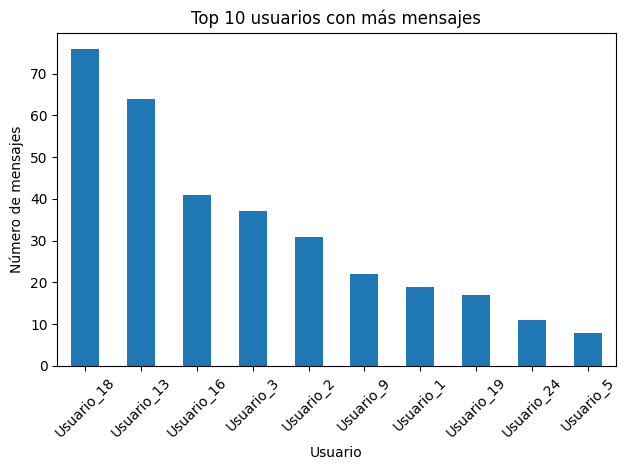

In [60]:
top_10 = messages_per_user.head(10)

top_10.plot(kind="bar")

plt.title("Top 10 usuarios con más mensajes")
plt.xlabel("Usuario")
plt.ylabel("Número de mensajes")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Frecuencia promedio de palabras por mensaje de texto de cada usuario

In [61]:
text_messages = df_analysis[
    df_analysis["message_type"] == "text"
]

avg_word_per_user = (
    text_messages
    .groupby("user_anon")["word_count"]
    .mean()
    .sort_values(ascending=False)
)

avg_word_per_user

user_anon
Usuario_7     130.000000
Usuario_3      60.000000
Usuario_10     56.250000
Usuario_27     47.000000
Usuario_4      43.000000
Usuario_1      42.200000
Usuario_8      40.166667
Usuario_9      30.916667
Usuario_16     29.533333
Usuario_2      29.052632
Usuario_26     28.600000
Usuario_13     26.615385
Usuario_5      24.833333
Usuario_18     20.240741
Usuario_19     16.307692
Usuario_24     13.000000
Usuario_17     12.000000
Usuario_6      10.000000
Usuario_28      9.600000
Usuario_22      5.000000
Usuario_21      3.000000
Usuario_11      2.500000
Usuario_15      2.000000
Usuario_20      2.000000
Usuario_14      1.000000
Usuario_12      1.000000
Usuario_25      1.000000
Name: word_count, dtype: float64

In [62]:
words_summary = (
    text_messages
    .groupby("user_anon")
    .agg(
        avg_words=("word_count", "mean"),
        text_messages=("message", "count")
    )
    .sort_values(by="avg_words", ascending=False)
)

words_summary

,avg_words,text_messages
user_anon,,
Usuario_7,130.000000,1
Usuario_3,60.000000,21
Usuario_10,56.250000,4
Usuario_27,47.000000,1
Usuario_4,43.000000,3
Usuario_1,42.200000,15
Usuario_8,40.166667,6
Usuario_9,30.916667,12
Usuario_16,29.533333,30


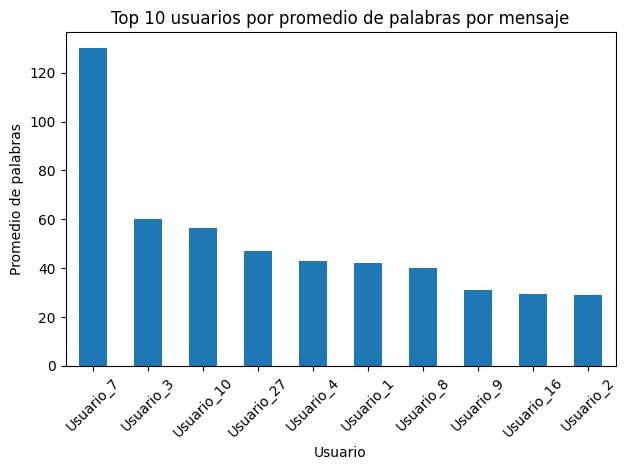

In [63]:
top_10_avg = words_summary.head(10)

top_10_avg["avg_words"].plot(kind="bar")

plt.title("Top 10 usuarios por promedio de palabras por mensaje")
plt.xlabel("Usuario")
plt.ylabel("Promedio de palabras")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

El **Usuario_7** presenta el promedio más alto, con **130 palabras por
mensaje**. Sin embargo, este resultado corresponde a un único mensaje,
por lo que no representa un patrón recurrente de actividad.

Entre los usuarios con mayor cantidad de mensajes de texto, destaca
el **Usuario_3**, con un promedio de **60 palabras por mensaje**
calculado sobre 21 mensajes.

## Usuario que más palabras envía, Usuario que mas emojis envia y el que envía más stickers

Se verificó manualmente que algunos registros <Media omitted> corresponden a stickers. Sin embargo, la exportación de WhatsApp no conserva el tipo específico del archivo multimedia, por lo que no es posible identificar sistemáticamente cuáles de los 110 registros multimedia corresponden a stickers. Por esta razón, no se determinó un usuario con mayor número de stickers.

### Usuario que más palabras envía

In [64]:
total_words_per_user = (
    text_messages
    .groupby("user_anon")["word_count"]
    .sum()
    .sort_values(ascending=False)
)

total_words_per_user

user_anon
Usuario_13    1384
Usuario_3     1260
Usuario_18    1093
Usuario_16     886
Usuario_1      633
Usuario_2      552
Usuario_9      371
Usuario_8      241
Usuario_10     225
Usuario_19     212
Usuario_5      149
Usuario_26     143
Usuario_7      130
Usuario_4      129
Usuario_24      78
Usuario_17      60
Usuario_28      48
Usuario_27      47
Usuario_6       10
Usuario_20       6
Usuario_22       5
Usuario_11       5
Usuario_21       3
Usuario_15       2
Usuario_14       1
Usuario_12       1
Usuario_25       1
Name: word_count, dtype: int64

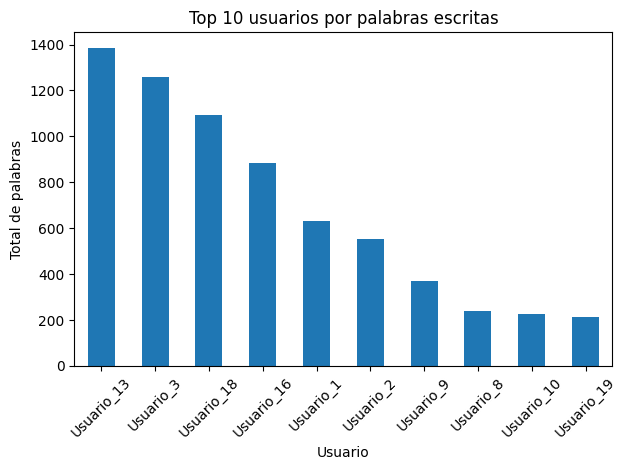

In [65]:
top_10_words = total_words_per_user.head(10)

top_10_words.plot(kind="bar")

plt.title("Top 10 usuarios por palabras escritas")
plt.xlabel("Usuario")
plt.ylabel("Total de palabras")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Usuario que envia mas emojis

In [66]:
test = "Hola gente 🚨🚨 mañana nos vemos ⚠️"

emoji.emoji_list(test)



[{'match_start': 11, 'match_end': 12, 'emoji': '🚨'},
 {'match_start': 12, 'match_end': 13, 'emoji': '🚨'},
 {'match_start': 31, 'match_end': 33, 'emoji': '⚠️'}]

In [67]:
len(emoji.emoji_list(test))

3

In [68]:
def count_emojis(message, message_type):
    if message_type != "text":
        return 0

    return len(emoji.emoji_list(message))

In [69]:
df_analysis["emoji_count"] = df_analysis.apply(
    lambda row: count_emojis(row["message"], row["message_type"]),
    axis=1
)

In [70]:
df_analysis[
    df_analysis["emoji_count"] > 0
][
    ["user_anon", "message", "emoji_count"]
].sort_values(
    "emoji_count",
    ascending=False
).head(10)

,user_anon,message,emoji_count
15,Usuario_5,🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨\nAVISO: Si tienen fotos signific...,13
354,Usuario_26,"🗣🗣🗣🗣🗣\n\n🔴 Hola, ya se pueden unir a los grupo...",9
365,Usuario_18,🚨🗣️🚨 ATENCIÓN 🚨🗣️🚨,6
369,Usuario_18,🗣️🚨🤑YA ESTA EL TORNEO DE SMASH EN EL AUDITORIO...,6
74,Usuario_9,Vengan al auditorio para las premiaciones🗣️🔥‼️🔥🗣️,5
59,Usuario_2,chic@s\n\nmañana venderemos *waffles* 🧇 frente...,4
69,Usuario_2,sobre el rompehielo🧊 mañana a las 12 🕛 mandare...,4
167,Usuario_19,YA ESTÁN LAS LIBRETAS EN EL CENTRO DE COMPUTO ...,4
165,Usuario_19,RECORDATORIO‼️‼️ recuerden los estudiantes de ...,4
78,Usuario_1,⚠️⚠️ CINECLUB ⚠️⚠️\n\nSe esta planeando la or...,4


In [71]:
emojis_per_user = (
    df_analysis
    .groupby("user_anon")["emoji_count"]
    .sum()
    .sort_values(ascending=False)
)

emojis_per_user

user_anon
Usuario_2     32
Usuario_19    24
Usuario_18    21
Usuario_1     16
Usuario_9     16
Usuario_5     13
Usuario_26    12
Usuario_13     8
Usuario_10     4
Usuario_4      3
Usuario_3      3
Usuario_8      1
Usuario_17     0
Usuario_14     0
Usuario_15     0
Usuario_16     0
Usuario_11     0
Usuario_12     0
Usuario_22     0
Usuario_20     0
Usuario_27     0
Usuario_25     0
Usuario_24     0
Usuario_23     0
Usuario_21     0
Usuario_28     0
Usuario_7      0
Usuario_6      0
Name: emoji_count, dtype: int64

El **Usuario_2** fue quien utilizó la mayor cantidad de emojis, con un total
de **32**, seguido por el **Usuario_19** con **24** y el **Usuario_18**
con **21**.

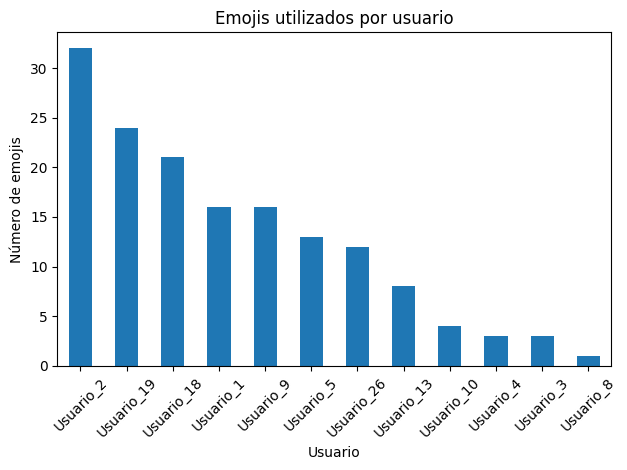

In [72]:
emoji_users = emojis_per_user[emojis_per_user > 0]

emoji_users.plot(kind="bar")

plt.title("Emojis utilizados por usuario")
plt.xlabel("Usuario")
plt.ylabel("Número de emojis")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Usuario con más stickers

No fue posible determinar qué usuario envió más stickers debido a una
limitación de la exportación de WhatsApp. Los archivos multimedia aparecen
registrados únicamente como `<Media omitted>`, sin indicar si corresponden
a imágenes, videos, GIFs o stickers.

Por esta razón, no se realizó un conteo de stickers, ya que clasificarlos
a partir de estos datos requeriría asumir información que no está presente
en el archivo exportado.

## Actividad por día de la semana

In [73]:
df_analysis[
    df_analysis["message"]
    .str.contains("sticker", case=False, na=False)
][["timestamp", "user_anon", "message"]]

,timestamp,user_anon,message
11,2023-12-01 09:08:00,Usuario_4,Anuncio: \nA todas las personas que usen locke...
16,2023-12-05 09:35:00,Usuario_4,Segundo aviso:\n\nA aquellas personas que no p...


In [74]:
messages_by_weekday = (
    valid_messages["weekday"]
    .value_counts()
)

messages_by_weekday

weekday
Thursday     83
Tuesday      75
Wednesday    75
Friday       69
Monday       63
Saturday      9
Sunday        6
Name: count, dtype: int64

El **jueves** fue el día con mayor actividad, con **83 mensajes**, mientras
que el **domingo** presentó la menor actividad, con solamente **6 mensajes**.

Se observa un patrón semanal claro: la actividad se concentra principalmente
de lunes a viernes, con entre 63 y 83 mensajes por día, mientras que durante
el fin de semana disminuye considerablemente, con 9 mensajes el sábado y
6 el domingo.

In [75]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

messages_by_weekday = (
    valid_messages["weekday"]
    .value_counts()
    .reindex(weekday_order, fill_value=0)
)

messages_by_weekday

weekday
Monday       63
Tuesday      75
Wednesday    75
Thursday     83
Friday       69
Saturday      9
Sunday        6
Name: count, dtype: int64

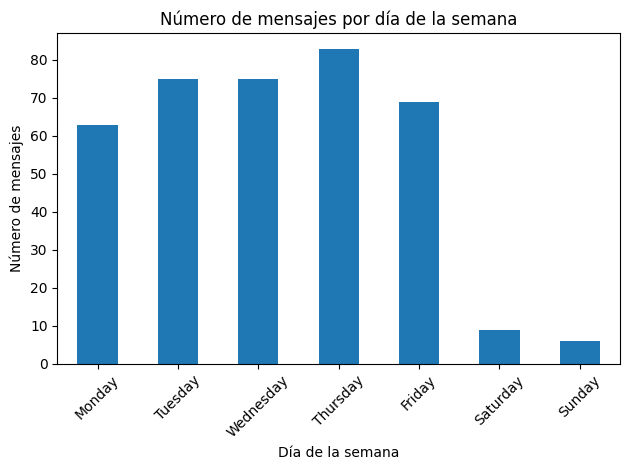

In [76]:
messages_by_weekday.plot(kind="bar")

plt.title("Número de mensajes por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Número de mensajes")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Actividad según la hora del día

La actividad del chat presenta un patrón temporal marcado. Los mensajes
comienzan a aumentar a partir de las **8:00**, alcanzando su punto máximo
alrededor de las **12:00**, con aproximadamente **64 mensajes**.

Después del mediodía, la actividad disminuye y se mantiene en niveles más
bajos durante la tarde y la noche. Entre la **1:00 y las 7:00** prácticamente
no se registra actividad.

En conjunto, los datos muestran que la mayor parte de la actividad del chat
se concentra durante la mañana y el mediodía.

In [77]:
messages_by_hour = (
    valid_messages["hour"]
    .value_counts()
    .reindex(range(24), fill_value=0)
)

messages_by_hour

hour
0      2
1      0
2      0
3      0
4      1
5      0
6      0
7      0
8     17
9     20
10    46
11    49
12    64
13    29
14    30
15    27
16    19
17    12
18    18
19     9
20    14
21    10
22     6
23     7
Name: count, dtype: int64

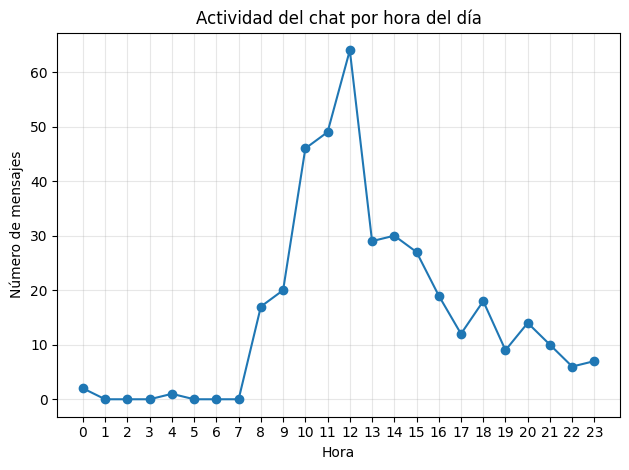

In [78]:
messages_by_hour.plot(
    kind="line",
    marker="o"
)

plt.title("Actividad del chat por hora del día")
plt.xlabel("Hora")
plt.ylabel("Número de mensajes")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## Análisis del contenido

### ¿Cuáles son las palabras más utilizadas por usuario y en general?

In [79]:
def tokenize(message):
    message = message.lower()

    words = re.findall(r"\b[a-záéíóúüñ]+\b", message)

    return words

In [80]:
df_analysis["tokens"] = df_analysis.apply(
    lambda row: tokenize(row["message_anon"])
    if row["message_type"] == "text"
    else [],
    axis=1
)

In [81]:
df_analysis[
    ["message", "message_type", "tokens"]
].head(10)

,message,message_type,tokens
0,"Gente, Coordinación me pidió que les informara...",text,"[gente, coordinación, me, pidió, que, les, inf..."
1,<Media omitted>,media,[]
2,dice Sonia que es *exclusivamente* frijol,text,"[dice, person, que, es, exclusivamente, frijol]"
3,"⚠️Recordatorio: Gente, Coordinación me pidió q...",text,"[recordatorio, gente, coordinación, me, pidió,..."
4,Tambien esto:,text,"[tambien, esto]"
5,Les reenvío este correo del Dr. Jesús \n\nFrom...,text,"[les, reenvío, este, correo, del, dr, person, ..."
6,<Media omitted>,media,[]
7,Los invito a que vayan a votar ahora por su je...,text,"[los, invito, a, que, vayan, a, votar, ahora, ..."
8,⚠️IMPORTANTE⚠️\nMañana 22 de noviembre es el e...,text,"[importante, mañana, de, noviembre, es, el, ev..."
9,This message was deleted,deleted,[]


In [82]:
all_words = []

for tokens in df_analysis["tokens"]:
    all_words.extend(tokens)

print("Total de palabras:", len(all_words))
print(all_words[:30])

Total de palabras: 7684
['gente', 'coordinación', 'me', 'pidió', 'que', 'les', 'informara', 'que', 'estamos', 'haciendo', 'una', 'colecta', 'y', 'que', 'mañana', 'es', 'importante', 'que', 'todos', 'procuren', 'traer', 'un', 'kg', 'de', 'frijol', 'la', 'bolsa', 'de', 'granos', 'de']


In [83]:
df_analysis["tokens"]

0      [gente, coordinación, me, pidió, que, les, inf...
1                                                     []
2        [dice, person, que, es, exclusivamente, frijol]
3      [recordatorio, gente, coordinación, me, pidió,...
4                                        [tambien, esto]
                             ...                        
385    [oigan, vamos, a, estar, entregando, libretas,...
386                            [enfrente, del, edificio]
387                                                   []
388                                   [en, el, hexágono]
389                                                   []
Name: tokens, Length: 390, dtype: object

In [84]:
word_counts = Counter(all_words)

word_counts.most_common(20)

[('de', 451),
 ('que', 264),
 ('a', 239),
 ('la', 227),
 ('el', 222),
 ('en', 187),
 ('para', 178),
 ('y', 175),
 ('los', 117),
 ('las', 113),
 ('se', 109),
 ('del', 81),
 ('es', 77),
 ('person', 68),
 ('por', 67),
 ('no', 62),
 ('con', 61),
 ('si', 57),
 ('una', 53),
 ('ya', 52)]

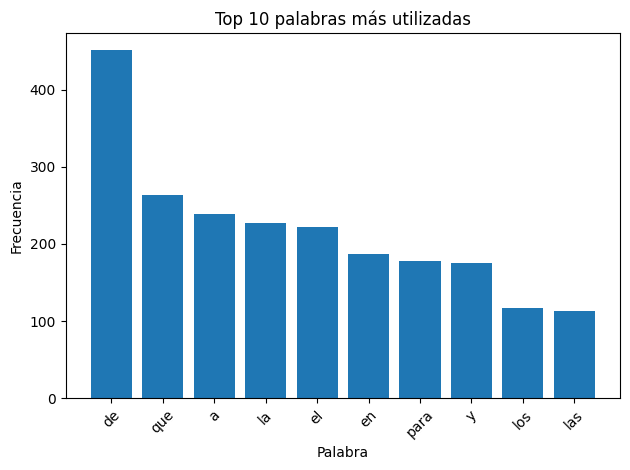

In [85]:
top_words = word_counts.most_common(10)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.bar(words, counts)

plt.title("Top 10 palabras más utilizadas")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### ¿Y cuáles son las más utilizadas excluyendo stopwords?

In [86]:
spanish_stopwords = set(stopwords.words("spanish"))

In [87]:
list(spanish_stopwords)[:20]

['fue',
 'él',
 'estés',
 'algunos',
 'estábamos',
 'con',
 'me',
 'vuestra',
 'tendríais',
 'tendré',
 'habrían',
 'sobre',
 'serás',
 'haya',
 'tuvieses',
 'qué',
 'estabas',
 'están',
 'por',
 'entre']

In [88]:
filtered_words = [
    word
    for word in all_words
    if word not in spanish_stopwords
]

In [89]:
filtered_word_counts = Counter(filtered_words)

filtered_word_counts.most_common(20)

[('person', 68),
 ('si', 57),
 ('https', 46),
 ('com', 33),
 ('cosas', 29),
 ('hola', 29),
 ('auditorio', 28),
 ('mañana', 24),
 ('hoy', 24),
 ('día', 22),
 ('pueden', 22),
 ('estudiantes', 21),
 ('va', 21),
 ('comunidad', 20),
 ('forms', 18),
 ('matemáticas', 17),
 ('semestre', 17),
 ('van', 17),
 ('lcc', 17),
 ('grupo', 17)]

In [90]:
custom_stopwords = {
    "https", "http", "com", "www",
    "person", "email", "phone", "financial",
    "si"
}

In [91]:
all_stopwords = spanish_stopwords.union(custom_stopwords)

In [92]:
filtered_words = [
    word
    for word in all_words
    if word not in all_stopwords
]

filtered_word_counts = Counter(filtered_words)

filtered_word_counts.most_common(20)

[('cosas', 29),
 ('hola', 29),
 ('auditorio', 28),
 ('mañana', 24),
 ('hoy', 24),
 ('día', 22),
 ('pueden', 22),
 ('estudiantes', 21),
 ('va', 21),
 ('comunidad', 20),
 ('forms', 18),
 ('matemáticas', 17),
 ('semestre', 17),
 ('van', 17),
 ('lcc', 17),
 ('grupo', 17),
 ('alumnos', 16),
 ('importante', 15),
 ('puede', 15),
 ('centro', 14)]

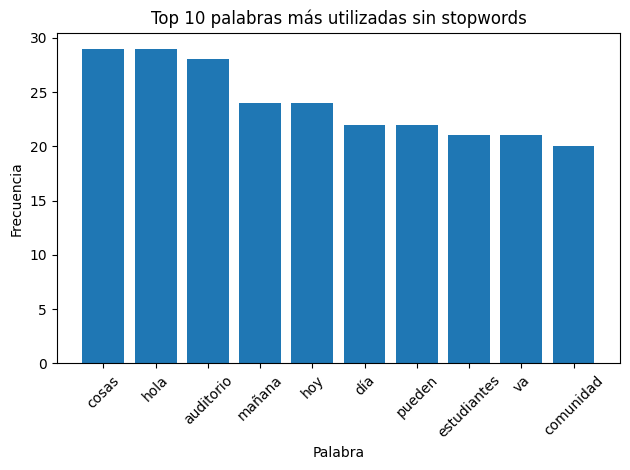

In [93]:
top_filtered_words = filtered_word_counts.most_common(10)

words = [word for word, count in top_filtered_words]
counts = [count for word, count in top_filtered_words]

plt.bar(words, counts)

plt.title("Top 10 palabras más utilizadas sin stopwords")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Panorama General de lo que se habla en el chat

In [94]:
all_words = []

for tokens in df_analysis["tokens"]:
    all_words.extend(tokens)

filtered_words = [
    word
    for word in all_words
    if word not in all_stopwords
]

filtered_word_counts = Counter(filtered_words)

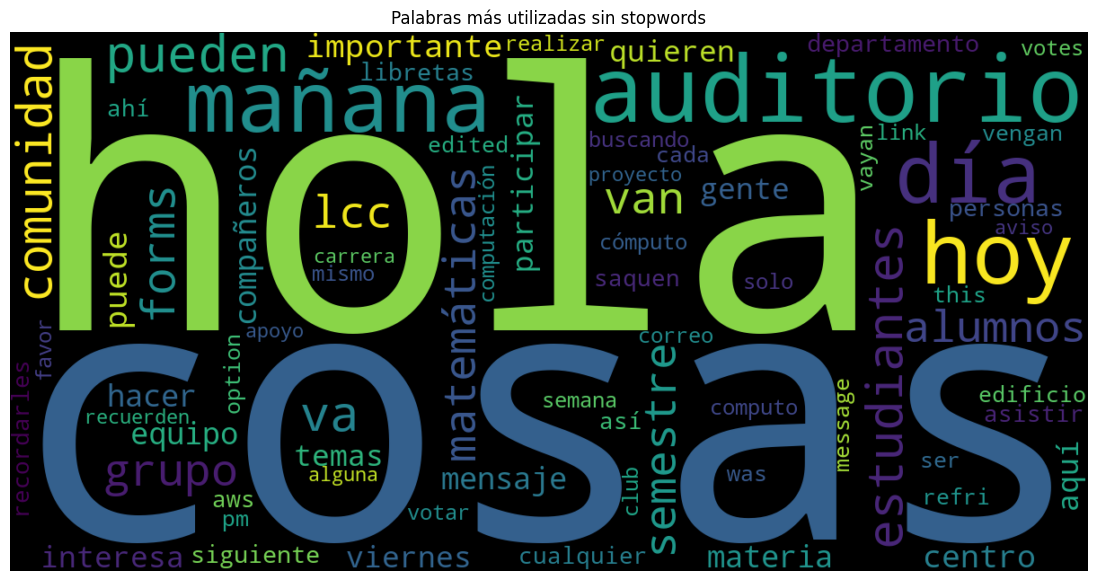

In [95]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="black",
    max_words=75
).generate_from_frequencies(filtered_word_counts)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Palabras más utilizadas sin stopwords")
plt.show()

### Palabras más utilizadas

Al considerar todas las palabras, las mayores frecuencias corresponden
principalmente a palabras funcionales como "de", "que", "a", "la" y "el".

Para obtener términos más representativos del contenido del chat, se
eliminaron stopwords del español, además de algunos términos generados por
URLs y por el proceso de anonimización.

Después del filtrado aparecen términos como "auditorio", "estudiantes",
"comunidad", "matemáticas", "semestre", "LCC", "grupo" y "alumnos", que
reflejan mejor el contexto académico y universitario de la conversación.

## Palabras mas usadas por usuario

In [96]:
def top_words_user(user, n=5):
    user_tokens = []

    for tokens in df_analysis.loc[
        df_analysis["user_anon"] == user,
        "tokens"
    ]:
        user_tokens.extend(tokens)

    filtered = [
        word
        for word in user_tokens
        if word not in all_stopwords
    ]

    return Counter(filtered).most_common(n)

In [97]:
top_words_by_user = {}

for user in df_analysis["user_anon"].unique():
    top_words_by_user[user] = top_words_user(user)

top_words_by_user

{'Usuario_1': [('importante', 7),
  ('mañana', 6),
  ('comunidad', 5),
  ('colecta', 4),
  ('frijol', 4)],
 'Usuario_2': [('s', 6),
  ('chic', 5),
  ('hoy', 4),
  ('actividades', 4),
  ('quieren', 4)],
 'Usuario_3': [('departamento', 11),
  ('matemáticas', 7),
  ('estudiantes', 6),
  ('preferencia', 6),
  ('comunidad', 5)],
 'Usuario_4': [('personas', 2),
  ('stickers', 2),
  ('lockers', 2),
  ('candados', 2),
  ('llevar', 2)],
 'Usuario_5': [('materia', 3),
  ('semestre', 2),
  ('lcc', 2),
  ('recuerden', 2),
  ('higiene', 2)],
 'Usuario_6': [('hoy', 1),
  ('cierran', 1),
  ('edificio', 1),
  ('saquen', 1),
  ('cosas', 1)],
 'Usuario_7': [('convocatoria', 2),
  ('mitacs', 2),
  ('globalink', 2),
  ('research', 2),
  ('internship', 2)],
 'Usuario_8': [('hola', 3),
  ('graduación', 3),
  ('fiesta', 3),
  ('aquí', 2),
  ('lcc', 2)],
 'Usuario_9': [('interesa', 4),
  ('auditorio', 3),
  ('participar', 3),
  ('manden', 3),
  ('vengan', 2)],
 'Usuario_10': [('forms', 3),
  ('ver', 2),
  ('m

In [98]:
rows = []

for user, top_words in top_words_by_user.items():
    row = {"user": user}

    for i, (word, count) in enumerate(top_words, start=1):
        row[f"word_{i}"] = word
        row[f"count_{i}"] = count

    rows.append(row)

top_words_df = pd.DataFrame(rows)

top_words_df

,user,word_1,count_1,word_2,count_2,word_3,count_3,word_4,count_4,word_5,count_5
0,Usuario_1,importante,7.0,mañana,6.0,comunidad,5.0,colecta,4.0,frijol,4.0
1,Usuario_2,s,6.0,chic,5.0,hoy,4.0,actividades,4.0,quieren,4.0
2,Usuario_3,departamento,11.0,matemáticas,7.0,estudiantes,6.0,preferencia,6.0,comunidad,5.0
3,Usuario_4,personas,2.0,stickers,2.0,lockers,2.0,candados,2.0,llevar,2.0
4,Usuario_5,materia,3.0,semestre,2.0,lcc,2.0,recuerden,2.0,higiene,2.0
5,Usuario_6,hoy,1.0,cierran,1.0,edificio,1.0,saquen,1.0,cosas,1.0
6,Usuario_7,convocatoria,2.0,mitacs,2.0,globalink,2.0,research,2.0,internship,2.0
7,Usuario_8,hola,3.0,graduación,3.0,fiesta,3.0,aquí,2.0,lcc,2.0
8,Usuario_9,interesa,4.0,auditorio,3.0,participar,3.0,manden,3.0,vengan,2.0
9,Usuario_10,forms,3.0,ver,2.0,materias,2.0,d,2.0,lista,2.0


## Adjetivos más utilizados!

In [99]:
test = "La reunión importante será mañana en el auditorio universitario."

doc = nlp(test)

for token in doc:
    print(token.text, token.pos_)

La DET
reunión NOUN
importante ADJ
será AUX
mañana NOUN
en ADP
el DET
auditorio NOUN
universitario ADJ
. PUNCT


In [100]:
adjectives = []

for message in df_analysis.loc[
    df_analysis["message_type"] == "text",
    "message_anon"
]:
    doc = nlp(message)

    for token in doc:
        if token.pos_ == "ADJ" and token.is_alpha:
            adjectives.append(token.lemma_.lower())

In [101]:
print("Adjetivos encontrados:", len(adjectives))
print(adjectives[:30])

Adjetivos encontrados: 354
['importante', 'crudo', 'importante', 'mayor', 'importante', 'crudo', 'importante', 'mayor', 'departamental', 'estudiant', 'interesante', 'valioso', 'importante', 'fuerte', 'mayoritario', 'individual', 'otro', 'mayoritario', 'deseable', 'representado', 'profundo', 'colectivo', 'técnico', 'único', 'departamental', 'considero', 'electoral', 'difícil', 'importante', 'plática']


In [102]:
adjective_counts = Counter(adjectives)

adjective_counts.most_common(20)

[('importante', 16),
 ('interesado', 13),
 ('nuevo', 12),
 ('siguiente', 11),
 ('primero', 11),
 ('último', 7),
 ('solo', 6),
 ('afuero', 5),
 ('mayor', 4),
 ('estudiant', 4),
 ('interesante', 4),
 ('segundo', 4),
 ('próximo', 4),
 ('buen', 4),
 ('buena', 4),
 ('estudiantil', 4),
 ('anterior', 4),
 ('académico', 3),
 ('planteado', 3),
 ('social', 3)]

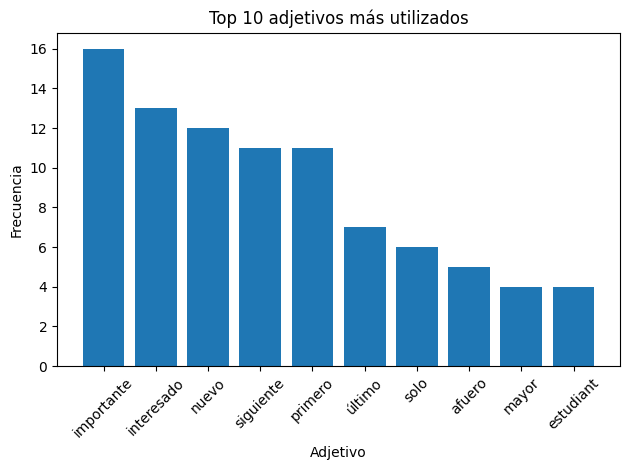

In [103]:
top_adjectives = adjective_counts.most_common(10)

words = [word for word, count in top_adjectives]
counts = [count for word, count in top_adjectives]

plt.bar(words, counts)

plt.title("Top 10 adjetivos más utilizados")
plt.xlabel("Adjetivo")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Para identificar los adjetivos se utilizó el modelo `es_core_news_sm`
de spaCy. Se seleccionaron los tokens clasificados como `ADJ` y formados
únicamente por caracteres alfabéticos.

Los adjetivos más frecuentes incluyen "importante", "interesado",
"nuevo", "siguiente" y "primero".

Debido a que el etiquetado gramatical es automático y los mensajes
provienen de conversaciones informales de WhatsApp, pueden existir
algunos errores de clasificación.

## Conclusiones

Como era de esperarse por la naturaleza del chat analizado, perteneciente a la comunidad de la carrera, gran parte de los mensajes están relacionados con avisos, actividades y eventos académicos. Esto también puede observarse en la nube de palabras, donde destacan términos relacionados con la comunidad universitaria, como "auditorio", "estudiantes", "matemáticas", "LCC", "semestre" y "comunidad".

En cuanto a los horarios, se observa que la mayor parte de la actividad ocurre durante el día, principalmente dentro de horarios relacionados con las actividades universitarias. La actividad comienza a aumentar a partir de las 8:00 y alcanza su punto máximo alrededor de las 12:00. Después disminuye progresivamente, aunque todavía existe actividad durante la tarde y noche.

También se encontró que la participación no está distribuida de manera uniforme entre los integrantes. Algunos usuarios concentran una cantidad considerablemente mayor de mensajes y palabras escritas que otros. Sin embargo, tener una mayor cantidad de mensajes no necesariamente implica escribir mensajes más largos, ya que los usuarios con mayor promedio de palabras por mensaje no coinciden necesariamente con quienes enviaron más mensajes.

Respecto al contenido multimedia, se encontraron 110 mensajes identificados como `<Media omitted>`. Sin embargo, la exportación de WhatsApp no permite distinguir si estos corresponden a imágenes, videos, stickers u otro tipo de archivo. Incluso después de verificar manualmente que algunos de estos registros corresponden a stickers, no es posible determinar de manera sistemática cuántos stickers envió cada usuario.

Finalmente, el análisis muestra que el chat se utiliza principalmente como un medio de comunicación relacionado con la vida académica y organizacional de la comunidad, con mensajes concentrados en horarios diurnos y un vocabulario fuertemente relacionado con actividades, espacios y temas universitarios.